In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
hp1 = pd.read_csv('train.csv')
hp1.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [3]:
hp1.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
hp1.isnull().sum() #hp1.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [5]:
missing_perc = hp1.isnull().sum()/len(hp1)*100
missing_perc.sort_values(ascending = False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [6]:
#50%+ NULL wale columns drop karo
cols_to_drop = missing_perc[missing_perc>50].index
hp1.drop(cols_to_drop,axis = 1, inplace = True)

In [7]:
#Missing % nikaalo
missing1 = hp1.isnull().sum()/len(hp1)*100
missing1.sort_values(ascending = False)

FireplaceQu      47.260274
LotFrontage      17.739726
GarageYrBlt       5.547945
GarageQual        5.547945
GarageFinish      5.547945
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 76, dtype: float64

In [8]:
#Numeric & Categorical alag karo
num_col = hp1.select_dtypes(include = ['int64','float64'])
cat_col = hp1.select_dtypes(include = ['object'])

In [9]:
#Missing Fill-->Numeric → Median
for col in num_col:
    hp1[col].fillna(hp1[col].median(),inplace = True)

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4436\4279549908.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hp1[col].fillna(hp1[col].median(),inplace = True)


In [10]:
#Categorical → Mode
for col in cat_col:
    hp1[col].fillna(hp1[col].mode()[0],inplace=True)

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4436\363538502.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hp1[col].fillna(hp1[col].mode()[0],inplace=True)


In [11]:
hp1.isna().sum().sum()

np.int64(0)

In [12]:
hp1.isna().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

In [13]:
hp1.info() #hp1.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [14]:
hp1.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenP

In [15]:
hp1['LotFrontage'].fillna(np.mean(hp1['LotFrontage']),inplace = True) # don't take mean bcs maybe has outlier then take a median
#or
#hp1['LotFrontage'].fillna(hp1['LotFrontage'].median(),inplace = True)
#or
# Location wise
#hp1['LotFrontage'] = hp1.groupby('Neighborhood')['LotFrontage']/.transform(lambda x:x.fillna(x.median()))

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4436\1290665829.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hp1['LotFrontage'].fillna(np.mean(hp1['LotFrontage']),inplace = True) # don't take mean bcs maybe has outlier then take a median


In [16]:
hp1.isna().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

In [17]:
hp1['LotFrontage'].isnull().sum()

np.int64(0)

In [18]:
print(hp1.shape)

(1460, 76)


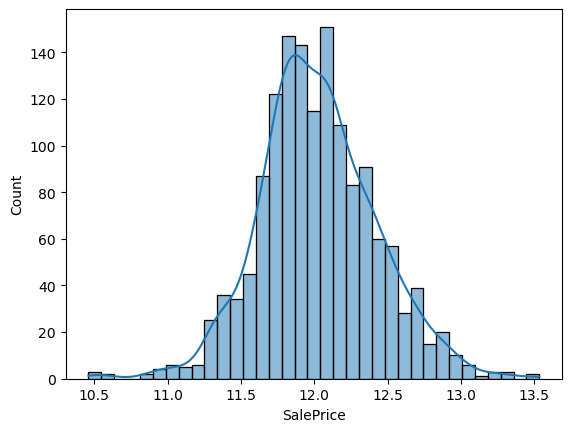

In [19]:
#Step 1: Target Variable (SalePrice) Distribution
hp1['SalePrice'] = np.log1p(hp1['SalePrice'])
sns.histplot(hp1['SalePrice'],kde = True)
plt.show()

In [20]:
Q1=num_col.quantile(0.25)
Q3=num_col.quantile(0.75)
IQR = Q3-Q1
#print(IQR)
outlier = ((num_col<(Q1-1.5*IQR)) | (num_col>(Q3+1.5*IQR))) #outlier = ((num_col<(Q1-1.5*IQR)) | (num_col>(Q3+1.5*IQR))).sum()
print(outlier)

         Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  \
0     False       False        False    False        False        False   
1     False       False        False    False        False         True   
2     False       False        False    False        False        False   
3     False       False        False    False        False        False   
4     False       False        False    False        False        False   
...     ...         ...          ...      ...          ...          ...   
1455  False       False        False    False        False        False   
1456  False       False        False    False        False        False   
1457  False       False        False    False        False         True   
1458  False       False        False    False        False        False   
1459  False       False        False    False        False        False   

      YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  WoodDeckSF  \
0         False         F

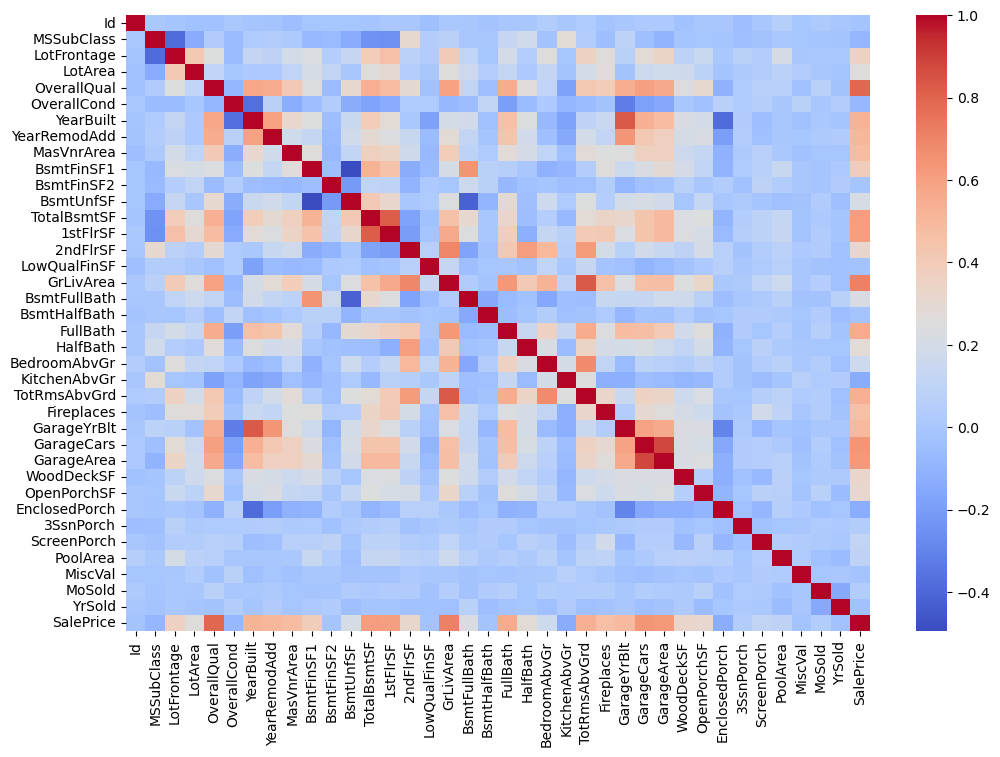

In [21]:
plt.figure(figsize = (12,8))
sns.heatmap(num_col.corr(),cmap = 'coolwarm')
plt.show()

In [22]:
#correlated future
#num_col.corr()
corr = hp1.corr(numeric_only=True)['SalePrice'].sort_values(ascending = False)
corr.head()
#or
#corr = num_cols.corr()['SalePrice'].sort_values(ascending=False)
#corr.head()

SalePrice      1.000000
OverallQual    0.817185
GrLivArea      0.700927
GarageCars     0.680625
GarageArea     0.650888
Name: SalePrice, dtype: float64

In [23]:
print(type(num_col))

<class 'pandas.core.frame.DataFrame'>


In [24]:
corr.tail()

YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePrice, dtype: float64

In [25]:
hp1.drop(['YrSold','LowQualFinSF','KitchenAbvGr','EnclosedPorch'], axis = 1,inplace = True)

In [26]:
hp1['MSSubClass'].value_counts()

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64

In [27]:
hp1['MSSubClass'] = hp1['MSSubClass'].astype(str)

In [28]:
hp1= pd.get_dummies(hp1,drop_first=True)

In [29]:
hp1.shape

(1460, 244)

In [30]:
#hp1['Neighborhood'] = hp1['Neighborhood'].apply(lambda x : x if hp1['Neighborhood'].value_counts()[x]<10 else 'other')

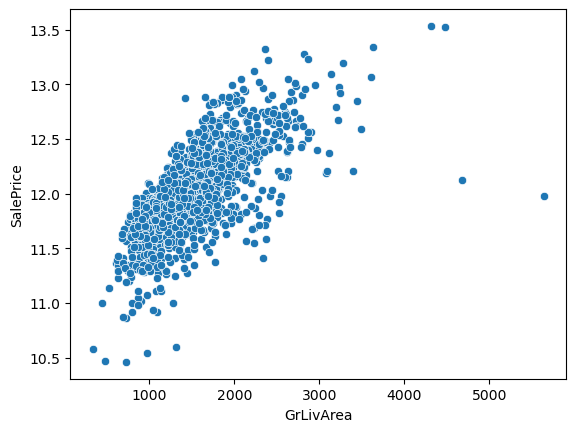

In [31]:
sns.scatterplot(x = 'GrLivArea',y = 'SalePrice', data = hp1)
plt.show()

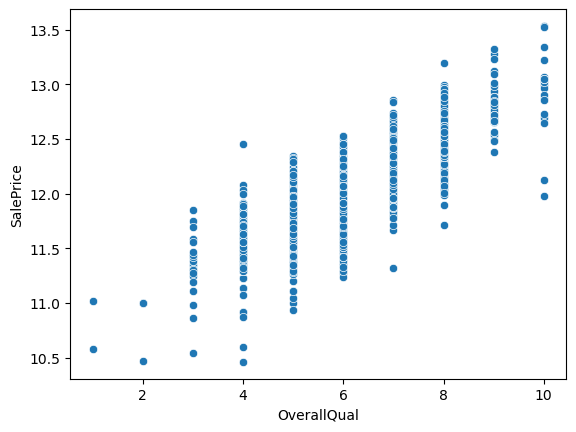

In [32]:
sns.scatterplot(x = 'OverallQual', y='SalePrice',data = hp1)
plt.show()

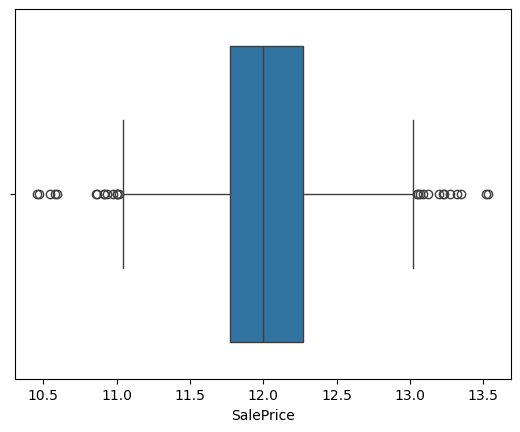

In [33]:
sns.boxplot(x = hp1['SalePrice'])
plt.show()

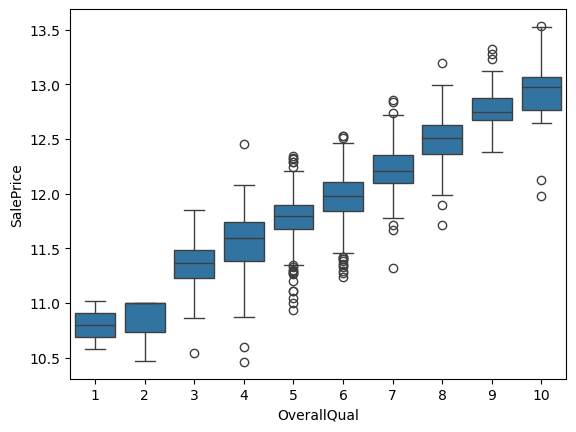

In [34]:
sns.boxplot(x='OverallQual',y = 'SalePrice' ,data= hp1)
plt.show()

In [35]:
hp1.columns

Index(['Id', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=244)

In [36]:
'SalePrice' in hp1.columns

True

In [37]:
hp1.columns.tolist()

['Id',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'SalePrice',
 'MSSubClass_160',
 'MSSubClass_180',
 'MSSubClass_190',
 'MSSubClass_20',
 'MSSubClass_30',
 'MSSubClass_40',
 'MSSubClass_45',
 'MSSubClass_50',
 'MSSubClass_60',
 'MSSubClass_70',
 'MSSubClass_75',
 'MSSubClass_80',
 'MSSubClass_85',
 'MSSubClass_90',
 'MSZoning_FV',
 'MSZoning_RH',
 'MSZoning_RL',
 'MSZoning_RM',
 'Street_Pave',
 'LotShape_IR2',
 'LotShape_IR3',
 'LotShape_Reg',
 'LandContour_HLS',
 'LandContour_Low',
 'LandContour_Lvl',
 'Utilities_NoSeWa',
 'LotConfig_CulDSac',
 'LotConfig_FR2',
 'LotConfig_FR

In [38]:
hp1['SalePrice'].head(5)

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64

In [39]:
x = hp1.drop('SalePrice',axis = 1)
y = hp1['SalePrice']

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
lr = LinearRegression()
lr.fit(x_train,y_train)

lr.score(x_test,y_test)

0.758622751279074

In [44]:
prd = lr.predict(x_test)
print('linear score',lr.score(x_test,y_test))

linear score 0.758622751279074


In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [46]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

In [47]:
rf.fit(x_train,y_train)
pred_rf = rf.predict(x_test)

In [48]:
print('Random score',rf.score(x_test,y_test))

Random score 0.880742063098723


In [49]:
from sklearn.linear_model import Ridge

In [50]:
ri = Ridge(alpha = 1.0)
ri.fit(x_train,y_train)
pred_ri = ri.predict(x_test)
print('Score',ri.score(x_test,y_test))

Score 0.8987995188381468


In [51]:
from sklearn.linear_model import Lasso

In [52]:
la = Lasso(alpha = 0.001)
la.fit(x_train,y_train)
pred_la = la.predict(x_test)
print('Lasso score',la.score(x_test,y_test))

Lasso score 0.8928302408618829


C:\Users\rizwa\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.085e+00, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(


In [53]:
from sklearn.tree import DecisionTreeRegressor

In [54]:
dt = DecisionTreeRegressor(random_state = 42)
dt.fit(x_train,y_train)
pred_dt = dt.predict(x_test)
print('Dt score',dt.score(x_test,y_test))

Dt score 0.7585488315536643


In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [56]:
kn = KNeighborsRegressor(n_neighbors = 5)
kn.fit(x_train,y_train)
pred_kn = kn.predict(x_test)
print('KNN Score',kn.score(x_test,y_test))

KNN Score 0.7178975331713222


In [57]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.fit_transform(x_test)
scal_kn = kn.fit(x_train_sc,y_train)
pred_scal = kn.predict(x_test_sc)
print('scaler_kn Score',kn.score(x_test_sc,y_test))

scaler_kn Score 0.7727795461069379


In [58]:
from sklearn.ensemble import GradientBoostingRegressor

In [59]:
gb = GradientBoostingRegressor(n_estimators = 200,learning_rate = 0.05,random_state = 42)
gb.fit(x_train,y_train)
pred_gb = gb.predict(x_test)
print('Gradient Boost Score',gb.score(x_test,y_test))

Gradient Boost Score 0.8945865137031721


In [60]:
#pip install xgboost

In [61]:
#pip install catboost

In [62]:
from catboost import CatBoostRegressor

In [63]:
cb = CatBoostRegressor(iterations = 500,learning_rate = 0.05,depth = 6,verbose = 0)
cb.fit(x_train,y_train)
pred_cb = cb.predict(x_test)
print('cat score',cb.score(x_test,y_test))

cat score 0.9073507311716489


In [64]:
model = ['Linear','Random','Ridge','Lasso','Dicision Tree','KNN-Scaler','Gradientboost','Catboost']
scores = [
    lr.score(x_test, y_test),
    rf.score(x_test, y_test),
    ri.score(x_test, y_test),
    la.score(x_test, y_test),
    dt.score(x_test, y_test),
    kn.score(x_test_sc, y_test),
    gb.score(x_test, y_test),
    cb.score(x_test, y_test)
]

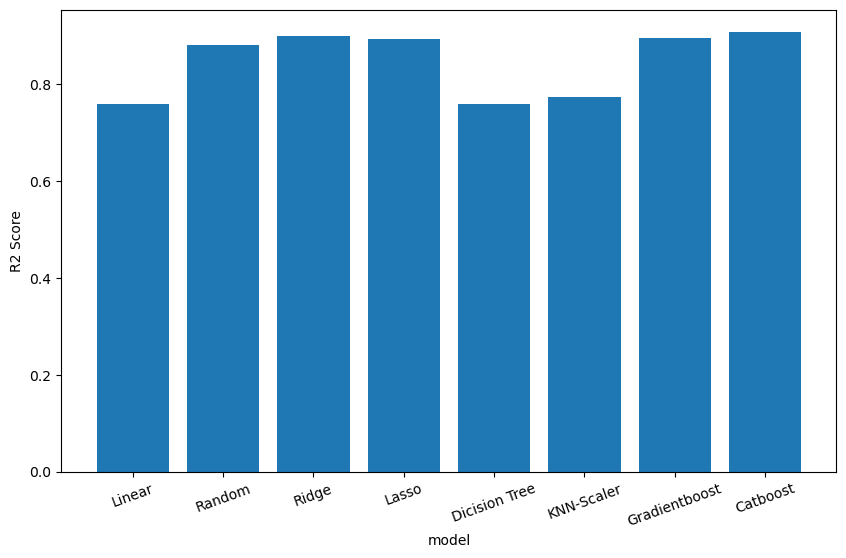

In [65]:
plt.figure(figsize = (10,6))
plt.bar(model,scores)
plt.xlabel('model')
plt.ylabel('R2 Score')
plt.xticks(rotation=20)
plt.show()

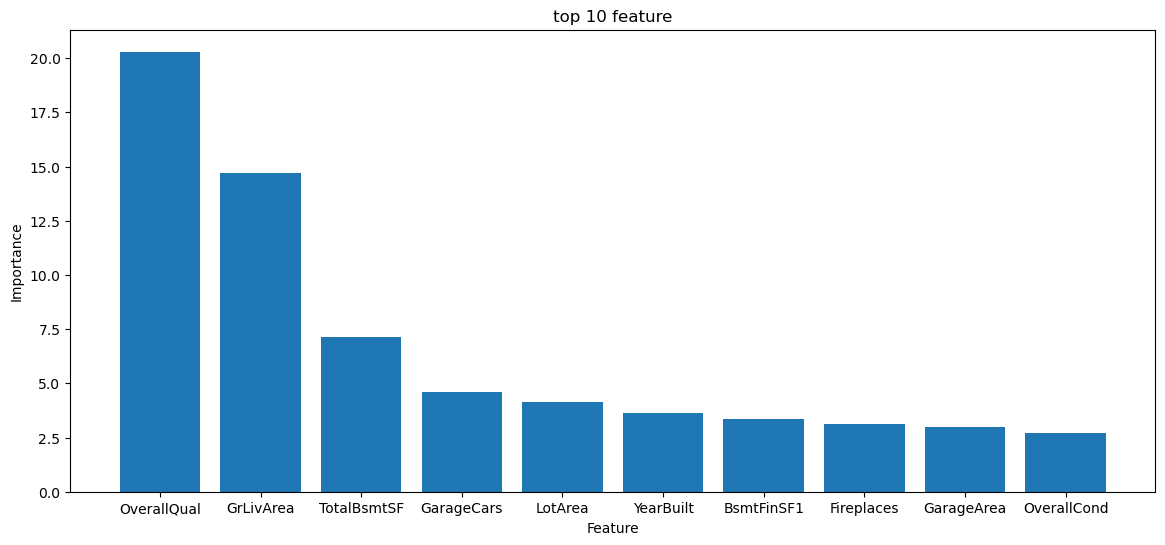

In [66]:
importance = cb.feature_importances_
feature_imp = pd.DataFrame({'Feature':x_train.columns,'Importance':importance})
feature_imp = feature_imp.sort_values(by = 'Importance',ascending =False).head(10)
plt.figure(figsize = (14,6))
plt.bar(feature_imp['Feature'],feature_imp['Importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('top 10 feature')
#plt.gca().invert_yaxis()
plt.show()

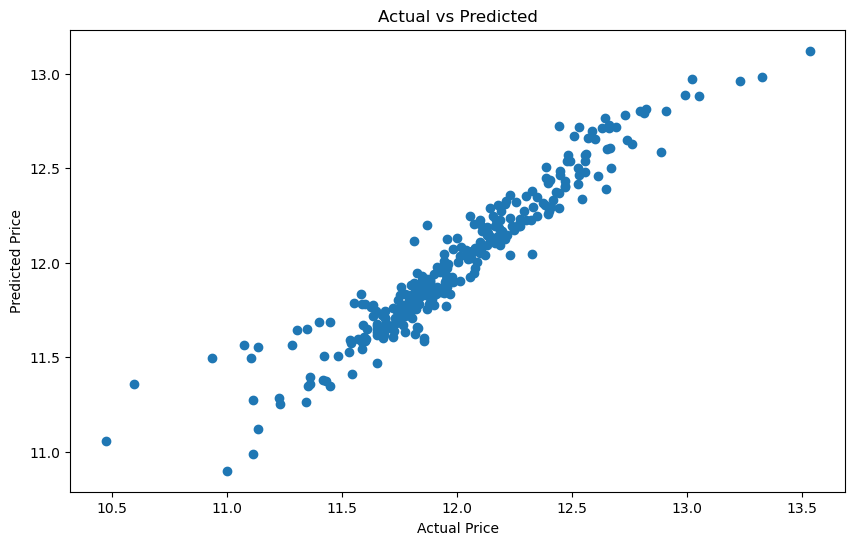

In [67]:
pred_cb = cb.predict(x_test)
plt.figure(figsize = (10,6))
plt.scatter(y_test,pred_cb)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [68]:
from sklearn.metrics import mean_squared_error

In [69]:
rmse = np.sqrt(mean_squared_error(y_test,pred_cb))
print('RMSE',rmse)

RMSE 0.1314890552407671


In [70]:
X = hp1.drop('SalePrice', axis=1)

In [71]:
X.shape

(1460, 243)

In [72]:
test = pd.read_csv("test.csv")

In [73]:
test.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [74]:
test['LotFrontage'].fillna(
    test['LotFrontage'].median(),
    inplace=True
)

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4436\3276275620.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['LotFrontage'].fillna(


In [75]:
test.isna().sum().sum()

np.int64(7651)

In [76]:
num_col = test.select_dtypes(include= ['int64','float64'])
cat_col= test.select_dtypes(include =['object'])

In [77]:
for col in num_col:
    test[col].fillna(test[col].median(),inplace = True)

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4436\833227148.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(test[col].median(),inplace = True)


In [82]:
for col in cat_col:
    test[col].fillna(test[col].mode()[0],inplace = True)

C:\Users\rizwa\AppData\Local\Temp\ipykernel_4436\1990566788.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(test[col].mode()[0],inplace = True)


In [83]:
test.isna().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 80, dtype: int64

In [84]:
test_ids = test['Id']

test = test.drop('Id', axis=1)

In [85]:
test = pd.get_dummies(test, drop_first=True)

In [86]:
test = test.reindex(columns=X.columns, fill_value=0)

In [87]:
final_pred = cb.predict(test)

In [88]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_pred
})

In [91]:
final_pred = np.expm1(final_pred)

In [92]:
final_pred.min()

np.float64(54003.345327200186)

In [94]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_pred
})

In [96]:
submission.head()

,Id,SalePrice
0,1461,126883.387980
1,1462,160450.842912
2,1463,183811.841808
3,1464,190166.597925
4,1465,185937.872382


In [97]:
submission.to_csv("submission.csv", index=False)